In [43]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
import scipy.stats as stats

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)


라이브러리 로드 완료!
한글 폰트 설정 완료!


In [44]:
# 1차 전처리 완료 데이터 로드
df = pd.read_csv('../../data/preprocessed.csv')
print("="*40)
print("데이터 로드 완료!")
print("="*40)
print(df.shape)
df.info()

데이터 로드 완료!
(640167, 26)
<class 'pandas.DataFrame'>
RangeIndex: 640167 entries, 0 to 640166
Data columns (total 26 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   index            640167 non-null  int64  
 1   course_id        640167 non-null  str    
 2   userid           640167 non-null  str    
 3   registered       640167 non-null  int64  
 4   viewed           640167 non-null  int64  
 5   explored         640167 non-null  int64  
 6   certified        640167 non-null  int64  
 7   country          640167 non-null  str    
 8   loe              640167 non-null  str    
 9   yob              640167 non-null  int64  
 10  gender           640167 non-null  str    
 11  grade            640167 non-null  float64
 12  start_time       640167 non-null  str    
 13  last_event       640167 non-null  str    
 14  nevents          441527 non-null  float64
 15  ndays_act        477898 non-null  float64
 16  nchapters        381772 n

연령 통계
count    640167.000000
mean         26.915141
std           8.222771
min          13.000000
25%          22.000000
50%          25.000000
75%          29.000000
max          82.000000
Name: age, dtype: float64

왜도: 1.972, 첨도: 5.125


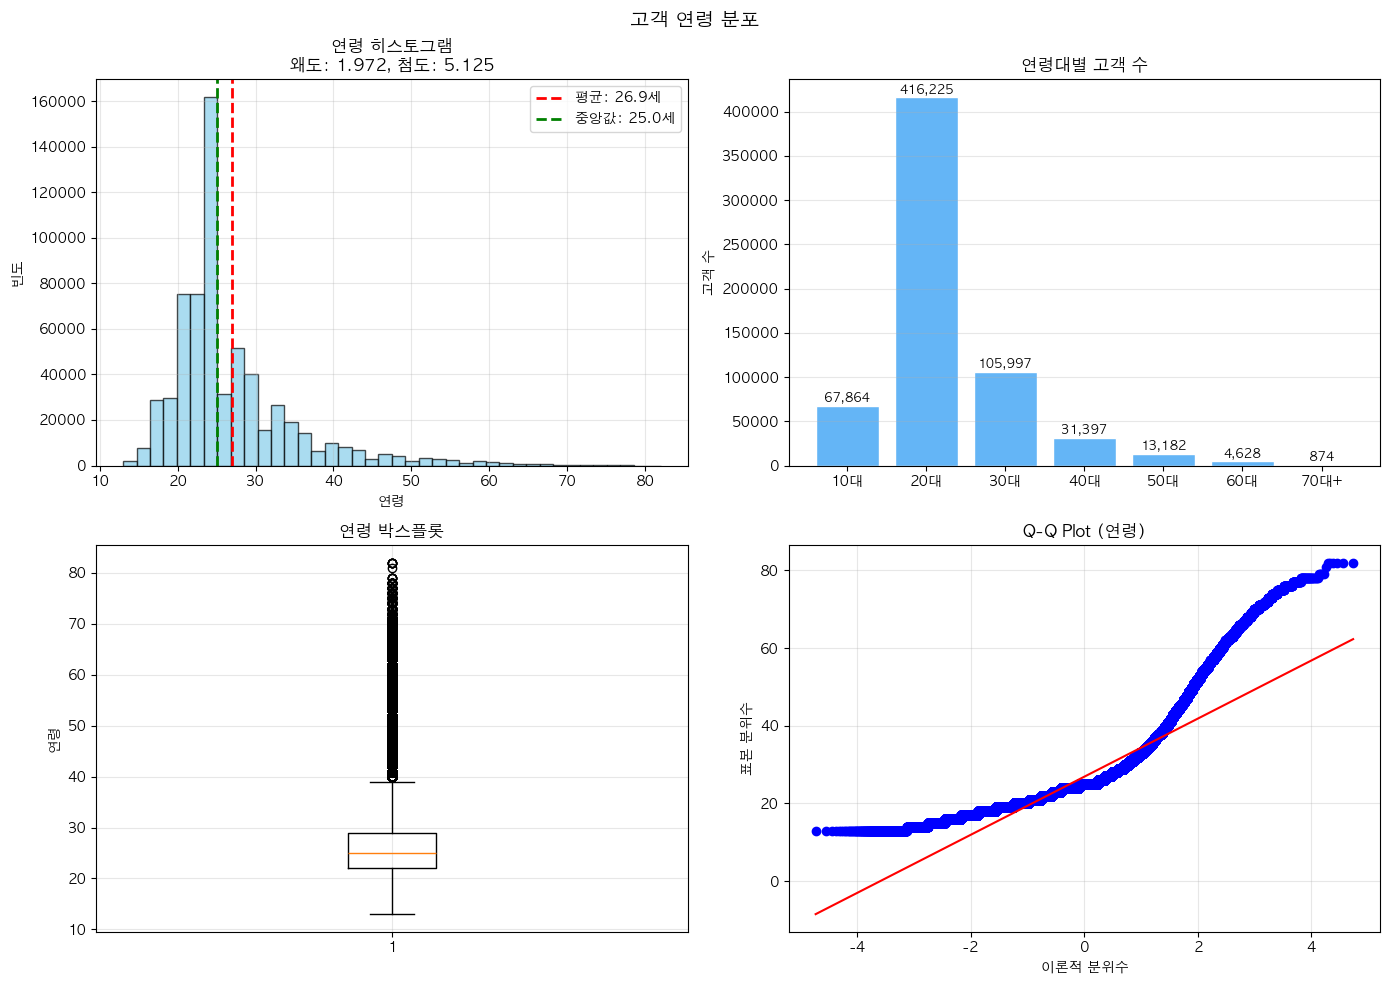

In [45]:
import scipy.stats as stats

# 연령대 컬럼 생성
bins = [0, 20, 30, 40, 50, 60, 70, 100]
labels = ['10대', '20대', '30대', '40대', '50대', '60대', '70대+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

age_skew = stats.skew(df['age'])
age_kurt = stats.kurtosis(df['age'])

print(f"연령 통계\n{df['age'].describe()}")
print(f"\n왜도: {age_skew:.3f}, 첨도: {age_kurt:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("고객 연령 분포", fontsize=14)

# 히스토그램
axes[0, 0].hist(df['age'], bins=40, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'평균: {df["age"].mean():.1f}세')
axes[0, 0].axvline(df['age'].median(), color='green', linestyle='--', linewidth=2,
                   label=f'중앙값: {df["age"].median():.1f}세')
axes[0, 0].set_title(f'연령 히스토그램\n왜도: {age_skew:.3f}, 첨도: {age_kurt:.3f}')
axes[0, 0].set_xlabel('연령')
axes[0, 0].set_ylabel('빈도')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 연령대별 막대그래프
age_group_counts = df['age_group'].value_counts().sort_index()
axes[0, 1].bar(range(len(age_group_counts)), age_group_counts.values,
               color='#64B5F6', edgecolor='white')
axes[0, 1].set_xticks(range(len(age_group_counts)))
axes[0, 1].set_xticklabels(age_group_counts.index)
axes[0, 1].set_title('연령대별 고객 수')
axes[0, 1].set_ylabel('고객 수')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(age_group_counts.values):
    axes[0, 1].text(i, v + age_group_counts.max() * 0.01, f'{v:,}', ha='center', fontsize=9)

# 박스플롯
axes[1, 0].boxplot(df['age'], vert=True)
axes[1, 0].set_title('연령 박스플롯')
axes[1, 0].set_ylabel('연령')
axes[1, 0].grid(True, alpha=0.3)

# QQ Plot
stats.probplot(df['age'], dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (연령)')
axes[1, 1].set_xlabel('이론적 분위수')
axes[1, 1].set_ylabel('표본 분위수')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

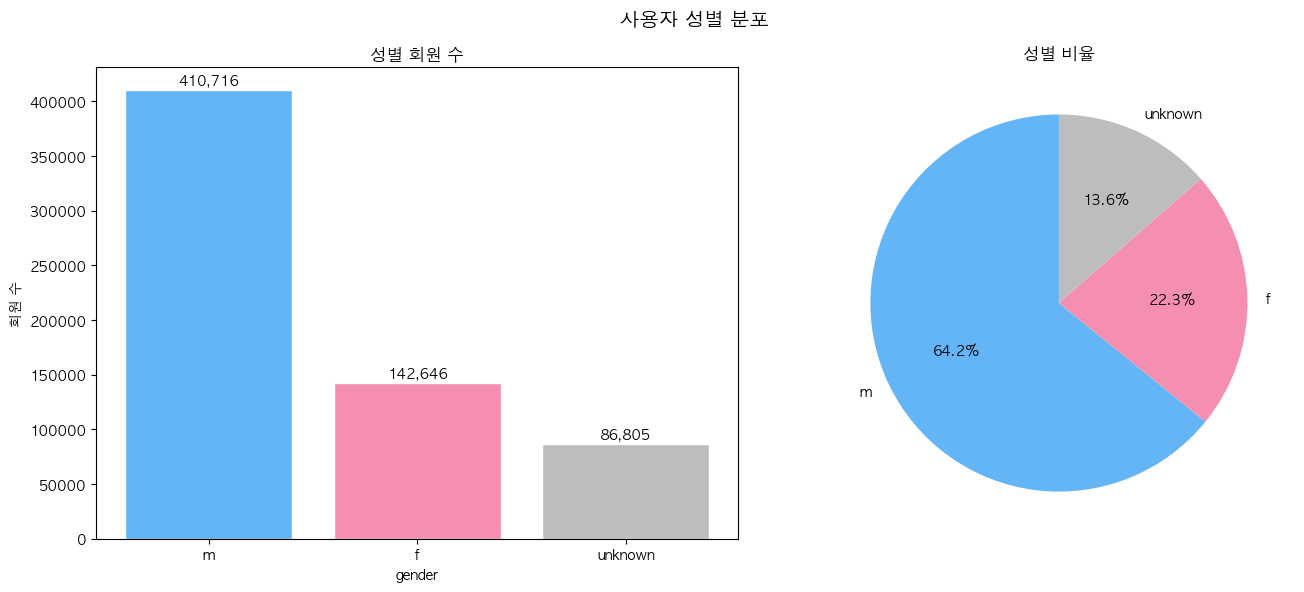


성별 회원 수:
          count  ratio
gender                
m        410716  64.16
f        142646  22.28
unknown   86805  13.56


In [46]:
gender_colors = {'m': '#64B5F6', 'f': '#F48FB1', 'unknown': '#BDBDBD'}
gender_counts = df['gender'].value_counts().reindex(['m', 'f', 'unknown'])
colors = [gender_colors[g] for g in gender_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("사용자 성별 분포", fontsize=14)

# 바 차트
axes[0].bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='white')
axes[0].set_title("성별 회원 수")
axes[0].set_xlabel("gender")
axes[0].set_ylabel("회원 수")
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + gender_counts.max() * 0.01, f'{v:,}', ha='center', fontsize=10)

# 파이 차트
axes[1].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title("성별 비율")

plt.tight_layout()
plt.show()

print("\n성별 회원 수:")
print(gender_counts.to_frame('count').assign(ratio=lambda x: (x['count'] / x['count'].sum() * 100).round(2)))

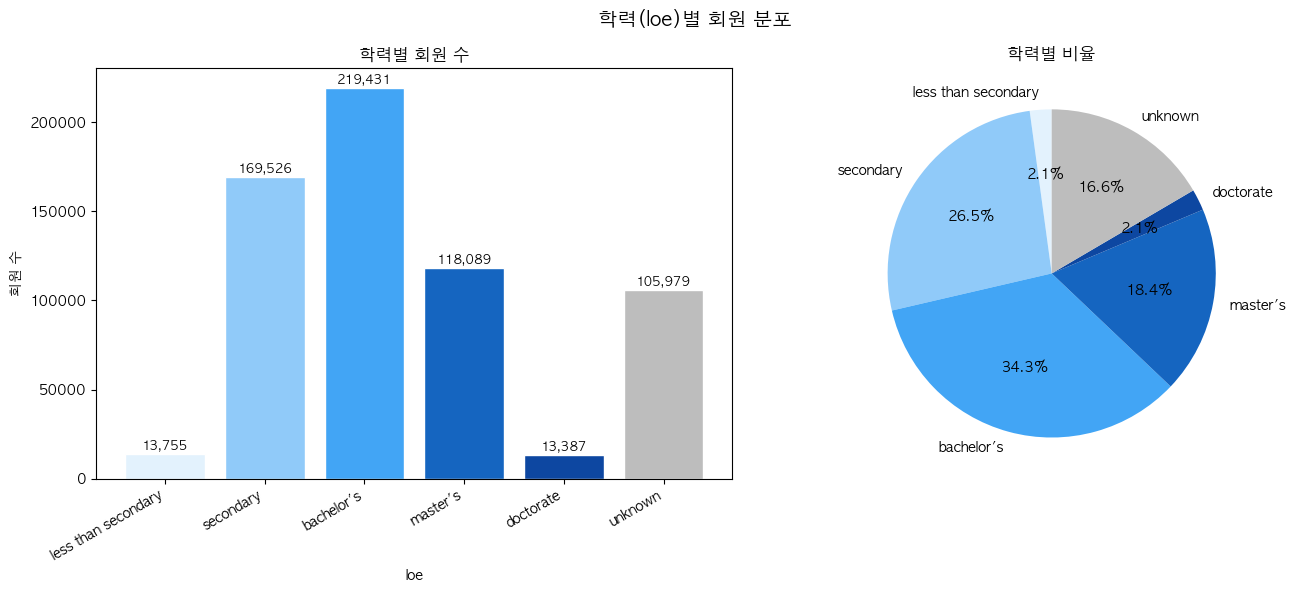


학력별 회원 수:
                      count  ratio
loe                               
less than secondary   13755   2.15
secondary            169526  26.48
bachelor's           219431  34.28
master's             118089  18.45
doctorate             13387   2.09
unknown              105979  16.55


In [47]:
loe_order = ["less than secondary", "secondary", "bachelor's", "master's", "doctorate", "unknown"]
loe_colors = ['#E3F2FD', '#90CAF9', '#42A5F5', '#1565C0', '#0D47A1', '#BDBDBD']

loe_counts = df['loe'].value_counts().reindex(loe_order)
colors = loe_colors

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("학력(loe)별 회원 분포", fontsize=14)

# 바 차트
axes[0].bar(range(len(loe_counts)), loe_counts.values, color=colors, edgecolor='white')
axes[0].set_xticks(range(len(loe_counts)))
axes[0].set_xticklabels(loe_counts.index, rotation=30, ha='right')
axes[0].set_title("학력별 회원 수")
axes[0].set_xlabel("loe")
axes[0].set_ylabel("회원 수")
for i, v in enumerate(loe_counts.values):
    axes[0].text(i, v + loe_counts.max() * 0.01, f'{v:,}', ha='center', fontsize=9)

# 파이 차트
axes[1].pie(loe_counts.values, labels=loe_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title("학력별 비율")

plt.tight_layout()
plt.show()

print("\n학력별 회원 수:")
print(loe_counts.to_frame('count').assign(ratio=lambda x: (x['count'] / x['count'].sum() * 100).round(2)))

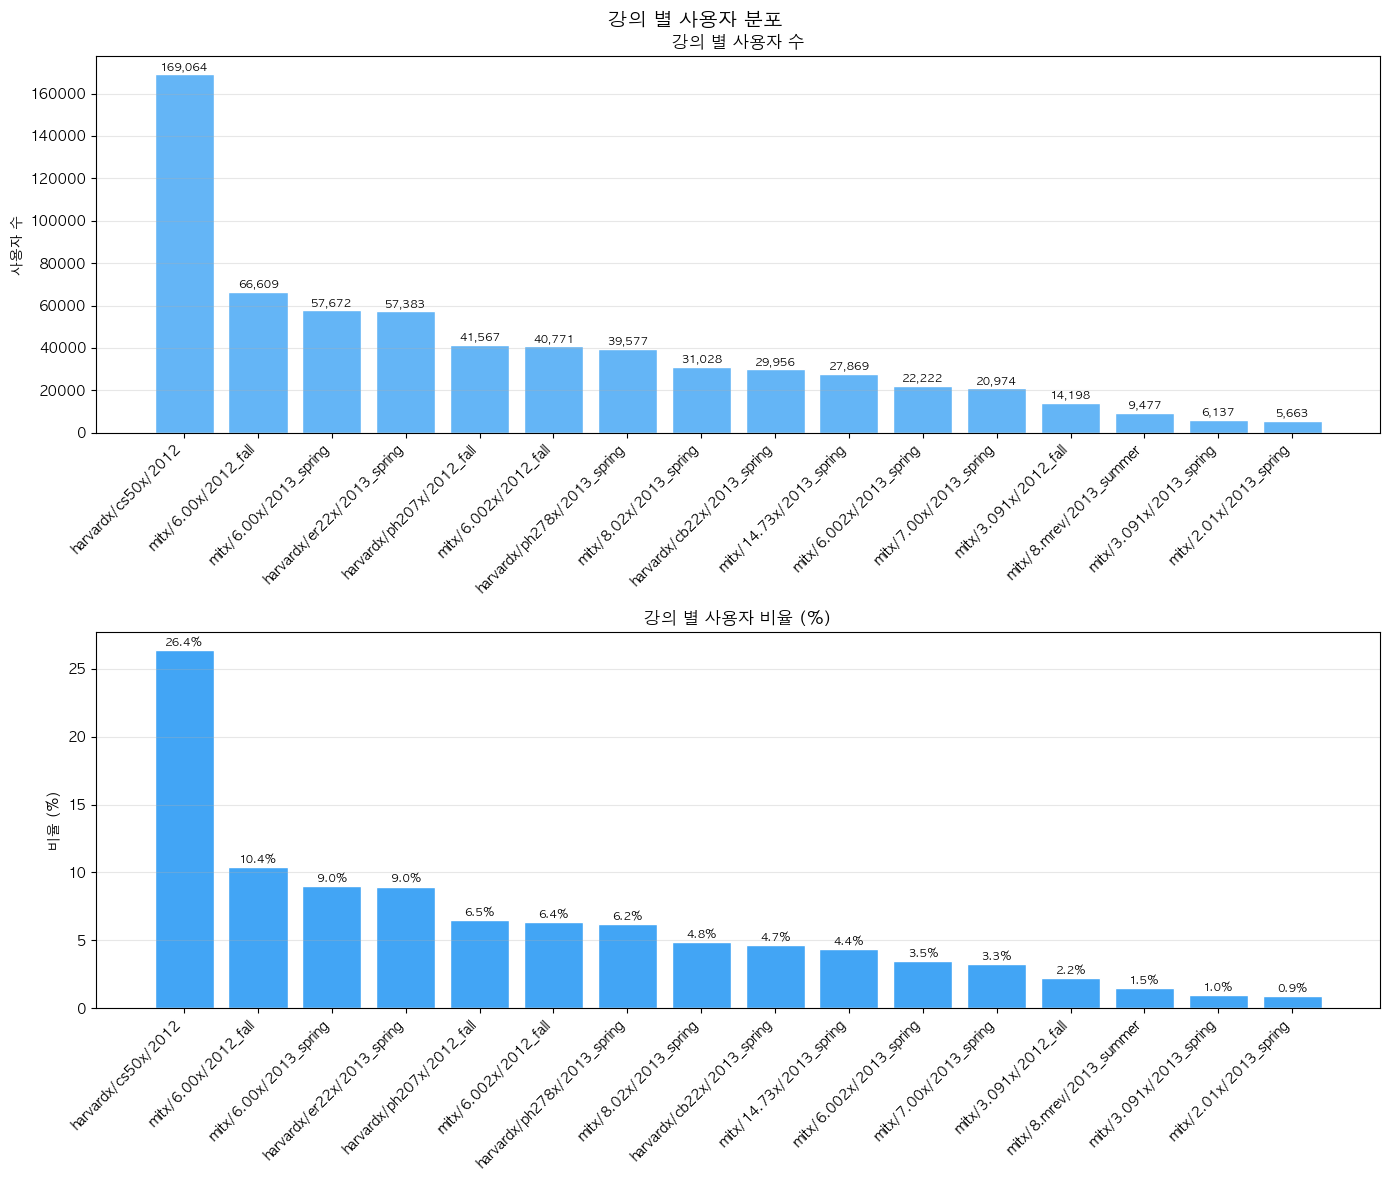

강의 별 사용자 수:
                              count  ratio
course_id                                 
harvardx/cs50x/2012          169064  26.41
mitx/6.00x/2012_fall          66609  10.40
mitx/6.00x/2013_spring        57672   9.01
harvardx/er22x/2013_spring    57383   8.96
harvardx/ph207x/2012_fall     41567   6.49
mitx/6.002x/2012_fall         40771   6.37
harvardx/ph278x/2013_spring   39577   6.18
mitx/8.02x/2013_spring        31028   4.85
harvardx/cb22x/2013_spring    29956   4.68
mitx/14.73x/2013_spring       27869   4.35
mitx/6.002x/2013_spring       22222   3.47
mitx/7.00x/2013_spring        20974   3.28
mitx/3.091x/2012_fall         14198   2.22
mitx/8.mrev/2013_summer        9477   1.48
mitx/3.091x/2013_spring        6137   0.96
mitx/2.01x/2013_spring         5663   0.88


In [48]:
# course_id별 사용자 수 집계
course_counts = df['course_id'].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle("강의 별 사용자 분포", fontsize=14)

# 바 차트 (절대 수)
axes[0].bar(range(len(course_counts)), course_counts.values, color='#64B5F6', edgecolor='white')
axes[0].set_xticks(range(len(course_counts)))
axes[0].set_xticklabels(course_counts.index, rotation=45, ha='right')
axes[0].set_title("강의 별 사용자 수")
axes[0].set_ylabel("사용자 수")
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(course_counts.values):
    axes[0].text(i, v + course_counts.max() * 0.01, f'{v:,}', ha='center', fontsize=8)

# 비율 바 차트
course_ratio = course_counts / course_counts.sum() * 100
axes[1].bar(range(len(course_ratio)), course_ratio.values, color='#42A5F5', edgecolor='white')
axes[1].set_xticks(range(len(course_ratio)))
axes[1].set_xticklabels(course_ratio.index, rotation=45, ha='right')
axes[1].set_title("강의 별 사용자 비율 (%)")
axes[1].set_ylabel("비율 (%)")
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(course_ratio.values):
    axes[1].text(i, v + course_ratio.max() * 0.01, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("강의 별 사용자 수:")
print(course_counts.to_frame('count').assign(ratio=lambda x: (x['count'] / x['count'].sum() * 100).round(2)))

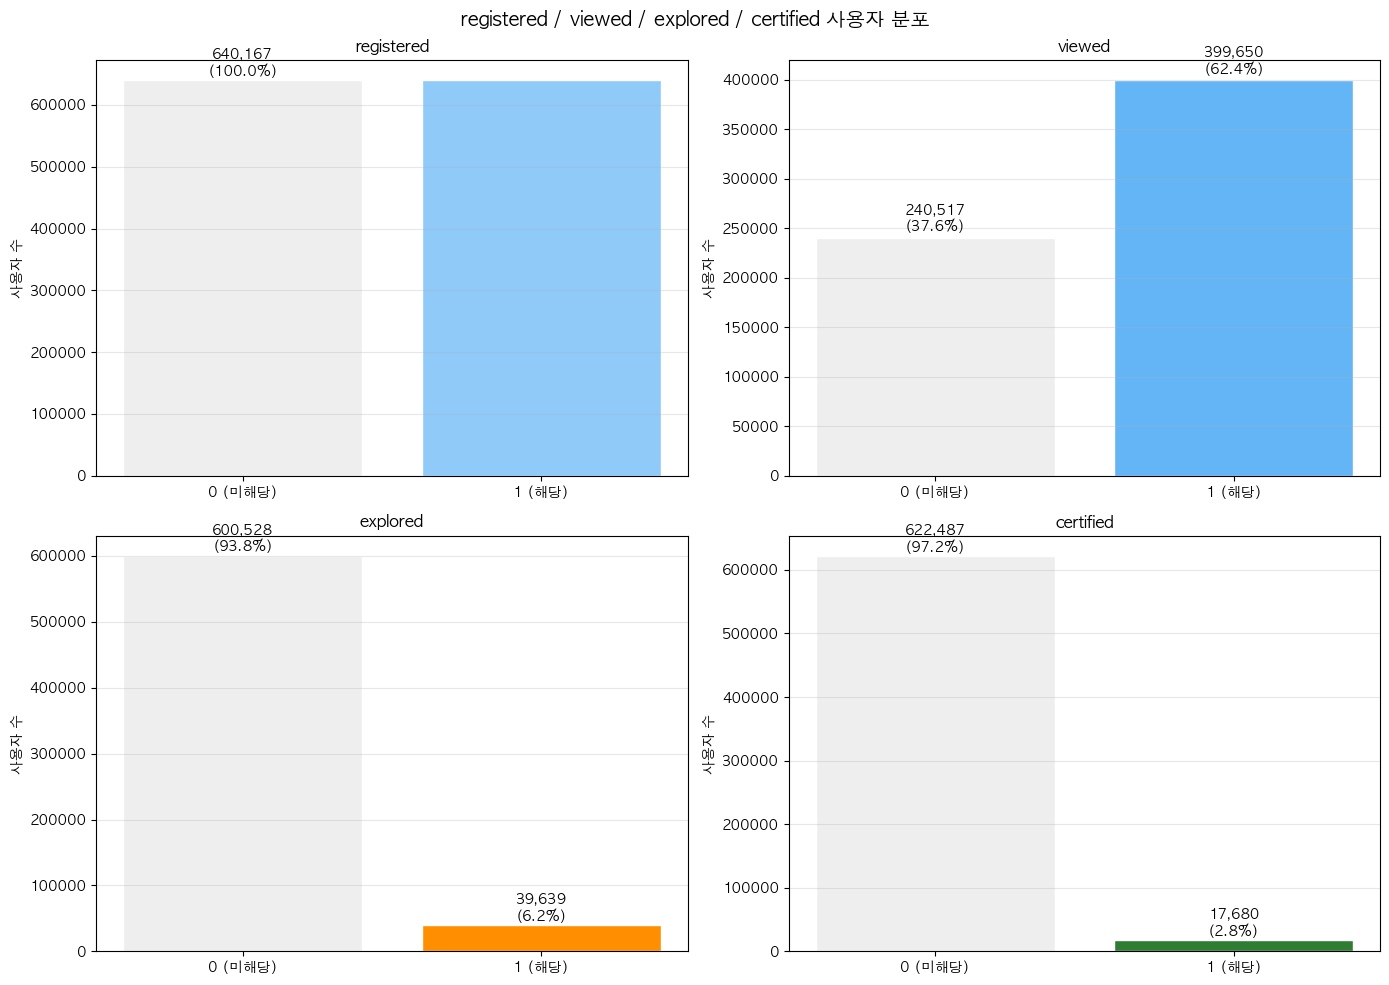


각 플래그별 사용자 수:

[registered]
             count  ratio
registered               
1           640167  100.0

[viewed]
         count  ratio
viewed               
0       240517  37.57
1       399650  62.43

[explored]
           count  ratio
explored               
0         600528  93.81
1          39639   6.19

[certified]
            count  ratio
certified               
0          622487  97.24
1           17680   2.76


In [49]:
flags = ['registered', 'viewed', 'explored', 'certified']
flag_colors = {'registered': '#90CAF9', 'viewed': '#64B5F6', 'explored': '#FF8F00', 'certified': '#2E7D32'}

# 각 플래그별 0/1 카운트
flag_counts = {col: df[col].value_counts().sort_index() for col in flags}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("registered / viewed / explored / certified 사용자 분포", fontsize=14)

for ax, col in zip(axes.flatten(), flags):
    counts = flag_counts[col]
    bars = ax.bar(['0 (미해당)', '1 (해당)'], counts.values,
                  color=['#EEEEEE', flag_colors[col]], edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel("사용자 수")
    ax.grid(True, alpha=0.3, axis='y')
    total = counts.sum()
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + total * 0.01,
                f'{v:,}\n({v/total*100:.1f}%)',
                ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n각 플래그별 사용자 수:")
for col in flags:
    counts = flag_counts[col]
    print(f"\n[{col}]")
    print(counts.to_frame('count').assign(ratio=lambda x: (x['count'] / x['count'].sum() * 100).round(2)))

duration 통계
count    461712.000000
mean         50.454290
std          77.582826
min        -381.000000
25%           0.000000
50%          11.000000
75%          73.000000
max         409.000000
Name: duration, dtype: float64

결측치: 178,455건 (27.9%)
음수값: 1,443건
0값:    151,415건


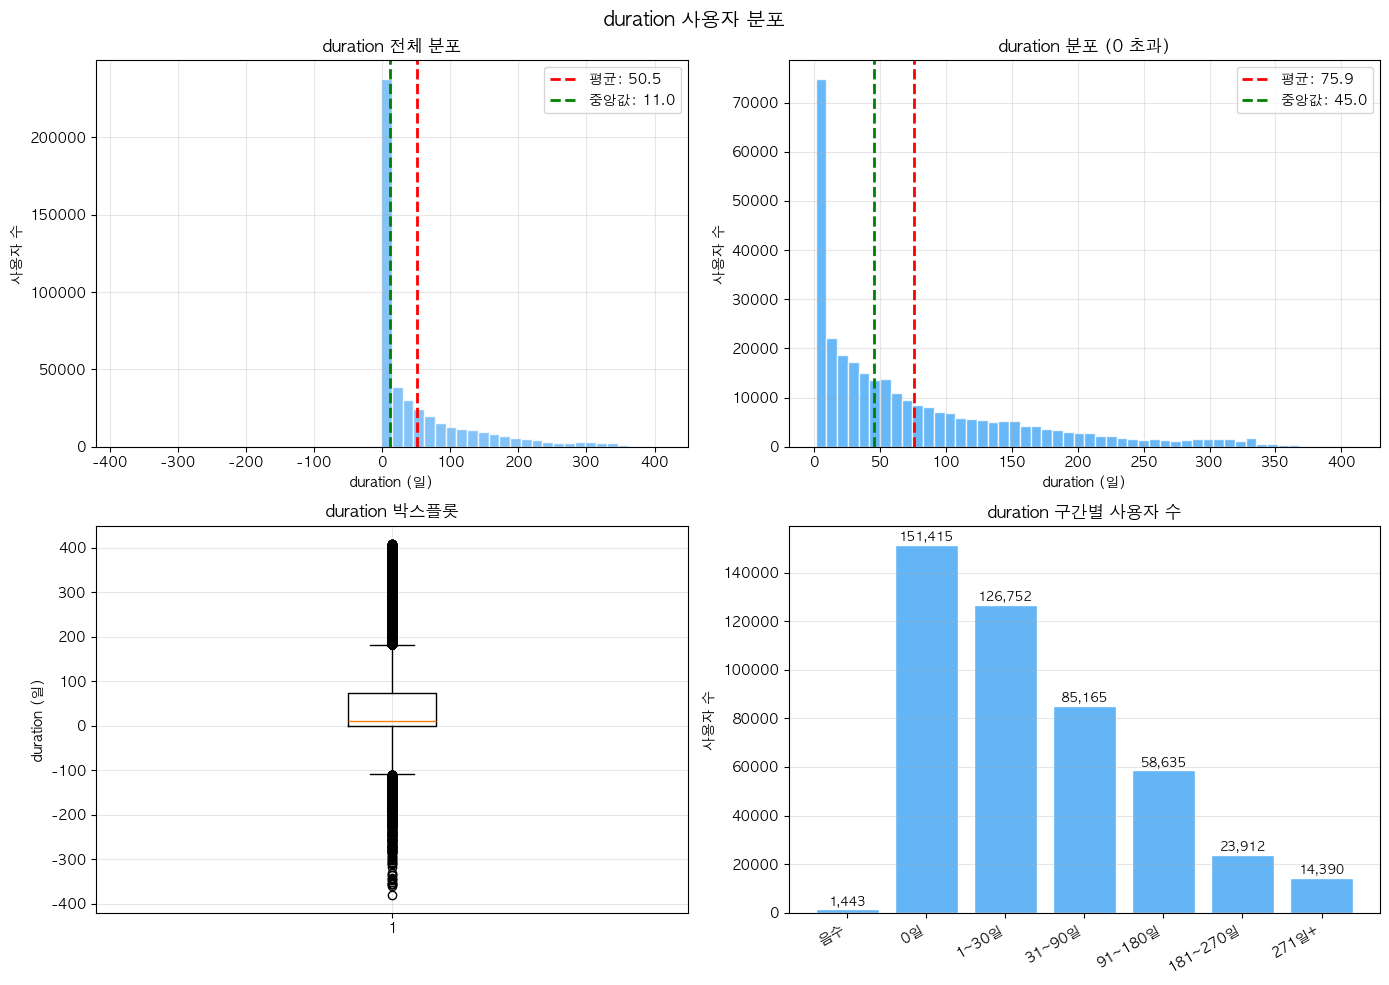

In [50]:
duration = df['duration'].dropna()
duration_neg = (duration < 0).sum()
duration_zero = (duration == 0).sum()

print(f"duration 통계")
print(duration.describe())
print(f"\n결측치: {df['duration'].isnull().sum():,}건 ({df['duration'].isnull().mean()*100:.1f}%)")
print(f"음수값: {duration_neg:,}건")
print(f"0값:    {duration_zero:,}건")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("duration 사용자 분포", fontsize=14)

# 전체 히스토그램
axes[0, 0].hist(duration, bins=50, color='#64B5F6', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(duration.mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {duration.mean():.1f}')
axes[0, 0].axvline(duration.median(), color='green', linestyle='--', linewidth=2, label=f'중앙값: {duration.median():.1f}')
axes[0, 0].set_title("duration 전체 분포")
axes[0, 0].set_xlabel("duration (일)")
axes[0, 0].set_ylabel("사용자 수")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 양수값만 히스토그램 (0 제외)
duration_pos = duration[duration > 0]
axes[0, 1].hist(duration_pos, bins=50, color='#42A5F5', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(duration_pos.mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {duration_pos.mean():.1f}')
axes[0, 1].axvline(duration_pos.median(), color='green', linestyle='--', linewidth=2, label=f'중앙값: {duration_pos.median():.1f}')
axes[0, 1].set_title("duration 분포 (0 초과)")
axes[0, 1].set_xlabel("duration (일)")
axes[0, 1].set_ylabel("사용자 수")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 박스플롯
axes[1, 0].boxplot(duration, vert=True)
axes[1, 0].set_title("duration 박스플롯")
axes[1, 0].set_ylabel("duration (일)")
axes[1, 0].grid(True, alpha=0.3)

# 음수/0/양수 구간별 카운트
bins_cat = [-float('inf'), -1, 0, 30, 90, 180, 270, float('inf')]
labels_cat = ['음수', '0일', '1~30일', '31~90일', '91~180일', '181~270일', '271일+']
duration_cat = pd.cut(duration, bins=bins_cat, labels=labels_cat, right=True)  # (-inf,-1]: 음수, (-1,0]: 0일)
cat_counts = duration_cat.value_counts().reindex(labels_cat)

axes[1, 1].bar(range(len(cat_counts)), cat_counts.values, color='#64B5F6', edgecolor='white')
axes[1, 1].set_xticks(range(len(cat_counts)))
axes[1, 1].set_xticklabels(labels_cat, rotation=30, ha='right')
axes[1, 1].set_title("duration 구간별 사용자 수")
axes[1, 1].set_ylabel("사용자 수")
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cat_counts.values):
    axes[1, 1].text(i, v + cat_counts.max() * 0.01, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

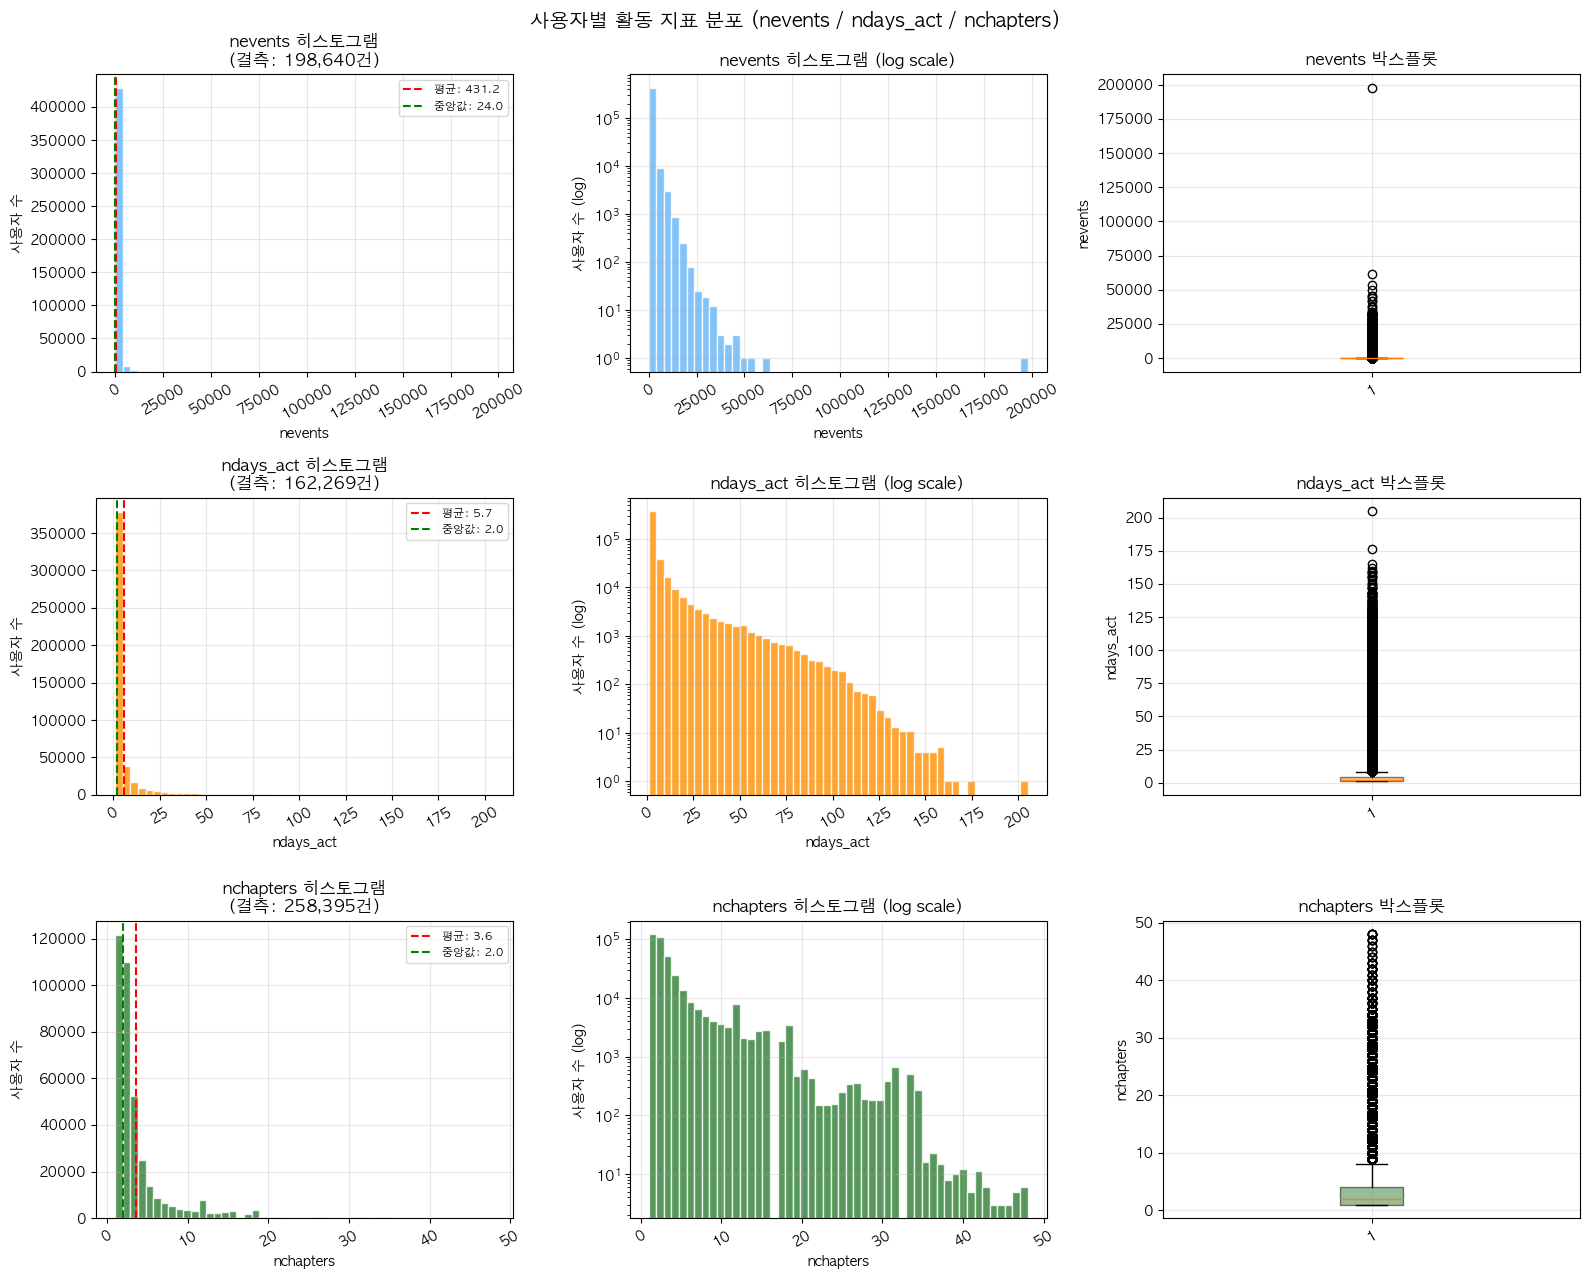

활동 지표 기술통계:


,nevents,ndays_act,nchapters
count,441527.000000,477898.000000,381772.000000
mean,431.171432,5.711353,3.635597
std,1516.511444,11.867918,4.492430
min,1.000000,1.000000,1.000000
25%,3.000000,1.000000,1.000000
50%,24.000000,2.000000,2.000000
75%,158.000000,4.000000,4.000000
max,197757.000000,205.000000,48.000000


In [51]:
activity_cols = ['nevents', 'ndays_act', 'nchapters']
colors = {'nevents': '#64B5F6', 'ndays_act': '#FF8F00', 'nchapters': '#2E7D32'}

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("사용자별 활동 지표 분포 (nevents / ndays_act / nchapters)", fontsize=14)

for row, col in enumerate(activity_cols):
    data = df[col].dropna()
    null_cnt = df[col].isnull().sum()
    color = colors[col]

    # 히스토그램
    axes[row, 0].hist(data, bins=50, color=color, edgecolor='white', alpha=0.8)
    axes[row, 0].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'평균: {data.mean():.1f}')
    axes[row, 0].axvline(data.median(), color='green', linestyle='--', linewidth=1.5, label=f'중앙값: {data.median():.1f}')
    axes[row, 0].set_title(f"{col} 히스토그램\n(결측: {null_cnt:,}건)")
    axes[row, 0].set_xlabel(col)
    axes[row, 0].set_ylabel("사용자 수")
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 0].tick_params(axis='x', rotation=30)

    # 로그 스케일 히스토그램
    axes[row, 1].hist(data, bins=50, color=color, edgecolor='white', alpha=0.8)
    axes[row, 1].set_yscale('log')
    axes[row, 1].set_title(f"{col} 히스토그램 (log scale)")
    axes[row, 1].set_xlabel(col)
    axes[row, 1].set_ylabel("사용자 수 (log)")
    axes[row, 1].grid(True, alpha=0.3)
    axes[row, 1].tick_params(axis='x', rotation=30)

    # 박스플롯
    axes[row, 2].boxplot(data, vert=True, patch_artist=True,
                         boxprops=dict(facecolor=color, alpha=0.5))
    axes[row, 2].set_title(f"{col} 박스플롯")
    axes[row, 2].set_ylabel(col)
    axes[row, 2].grid(True, alpha=0.3)
    axes[row, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("활동 지표 기술통계:")
display(df[activity_cols].describe())

# 활동 지표 범주화
### engagement_level 컬럼 생성  
- 'no_activity' : viewed=0  
- 'viewer'      : viewed=1 & explored=0 & certified=0
- 'explorer'    : explored=1 & certified=0
- 'completer'   : certified=1

In [52]:
# 활동지표 범주화
conditions = [
    df['certified'] == 1,
    (df['explored'] == 1) & (df['certified'] == 0),
    (df['viewed'] == 1) & (df['explored'] == 0) & (df['certified'] == 0),
    df['viewed'] == 0,
]
choices = ['completer', 'explorer', 'viewer', 'no_activity']
df['engagement_level'] = np.select(conditions, choices, default='no_activity')

df['engagement_level'].value_counts()

engagement_level
viewer         359322
no_activity    240517
explorer        22648
completer       17680
Name: count, dtype: int64

# 결측치 처리

### 강의 별 그룹 + engagement_level 별 그룹을 묶은 데이터 기반

- no_activiate 그룹은 결측치 일단 유지

In [53]:
# course_id 및 engagement_level 그룹별 활동 지표 결측치 확인
activity_metrics = ['nchapters', 'ndays_act', 'nevents']

# 그룹화하여 결측치 개수 계산
grouped_nulls = df.groupby(['course_id', 'engagement_level'])[activity_metrics].apply(lambda x: x.isnull().sum())

print("코스별 + 참여도별 활동 지표 결측치 수 확인:")
display(grouped_nulls)

# 결측치 비율(%)로 확인하고 싶은 경우를 위한 표
grouped_null_ratio = df.groupby(['course_id', 'engagement_level'])[activity_metrics].apply(lambda x: (x.isnull().sum() / len(x)) * 100)
print("\n코스별 + 참여도별 활동 지표 결측치 비율(%):")
display(grouped_null_ratio)

코스별 + 참여도별 활동 지표 결측치 수 확인:


nchapters  ndays_act  nevents
course_id                  engagement_level                               
harvardx/cb22x/2013_spring completer                 0          0        0
                           explorer                  0          0        0
                           no_activity           13587       5665     6975
                           viewer                  163         56       65
harvardx/cs50x/2012        completer                 0          1        1
...                                                ...        ...      ...
mitx/8.02x/2013_spring     viewer                  148        359      796
mitx/8.mrev/2013_summer    completer                 0          0        0
                           explorer                  0          0        0
                           no_activity            2651        518     1089
                           viewer                   82          3        3

[64 rows x 3 columns]


코스별 + 참여도별 활동 지표 결측치 비율(%):


nchapters  ndays_act    nevents
course_id                  engagement_level                                 
harvardx/cb22x/2013_spring completer          0.000000   0.000000   0.000000
                           explorer           0.000000   0.000000   0.000000
                           no_activity       99.400102  41.444144  51.027873
                           viewer             1.035578   0.355781   0.412961
harvardx/cs50x/2012        completer          0.000000   0.077821   0.077821
...                                                ...        ...        ...
mitx/8.02x/2013_spring     viewer             0.780015   1.892063   4.195215
mitx/8.mrev/2013_summer    completer          0.000000   0.000000   0.000000
                           explorer           0.000000   0.000000   0.000000
                           no_activity       96.015936  18.761318  39.442231
                           viewer             1.299525   0.047544   0.047544

[64 rows x 3 columns]

### 중앙값 대체
- viewer, explored

In [54]:
# course_id 및 engagement_level 그룹별 활동 지표 중앙값 확인
activity_metrics = ['nchapters', 'ndays_act', 'nevents']

grouped_median = df.groupby(['course_id', 'engagement_level'])[activity_metrics].median()

print("코스별 + 참여도별 활동 지표 중앙값 확인:")
display(grouped_median)

코스별 + 참여도별 활동 지표 중앙값 확인:


nchapters  ndays_act  nevents
course_id                  engagement_level                               
harvardx/cb22x/2013_spring completer              26.0       33.0   2292.0
                           explorer               21.0       20.0   1418.0
                           no_activity             2.0        1.0      2.0
                           viewer                  2.0        2.0     39.0
harvardx/cs50x/2012        completer              12.0       33.0    235.5
...                                                ...        ...      ...
mitx/8.02x/2013_spring     viewer                  2.0        3.0     81.0
mitx/8.mrev/2013_summer    completer              32.0       38.0   6568.0
                           explorer               29.0       26.0   4337.0
                           no_activity             1.0        1.0      1.0
                           viewer                  2.0        2.0     62.0

[64 rows x 3 columns]

In [55]:
# explorer, viewer 그룹의 활동 지표 결측치를 코스별 + 참여도별 중앙값으로 대체
activity_metrics = ['nchapters', 'ndays_act', 'nevents']
target_levels = ['explorer', 'viewer']

for level in target_levels:
    for col in activity_metrics:
        mask = (df['engagement_level'] == level) & df[col].isnull()
        df.loc[mask, col] = df.loc[mask].apply(
            lambda row: grouped_median.loc[(row['course_id'], level), col]
            if (row['course_id'], level) in grouped_median.index else np.nan,
            axis=1
        )

print("결측치 대체 후 engagement_level별 결측치 수:")
target_df = df[df['engagement_level'].isin(target_levels)]
print(target_df.groupby('engagement_level')[activity_metrics].apply(lambda x: x.isnull().sum()))
print("대체 후 no_activity (nchapters>=1 해당 행) 활동 지표 확인:")

결측치 대체 후 engagement_level별 결측치 수:
                  nchapters  ndays_act  nevents
engagement_level                               
explorer                  0          0        0
viewer                    0          0        0
대체 후 no_activity (nchapters>=1 해당 행) 활동 지표 확인:


# 이상치 제거

In [ ]:
# viewed = 0 & nchapters.max() 인 이상치 데이터 제거
df.loc[(df['viewed']==0 & df['nchapters'].notna()), 'nchapters'].describe()
max_nchapters = df.loc[(df['viewed'] == 0) & (df['nchapters'].notna()), 'nchapters'].max()
print('max_nchapters:', max_nchapters)

before = len(df)
drop_mask = (df['viewed'] == 0) & (df['nchapters'] == max_nchapters)
df = df[~drop_mask]

print(f"제거 전 행 수: {before:,}")
print(f"제거 후 행 수: {len(df):,}")
print(f"제거된 행 수: {before - len(df):,}")

print("")
print("="*40)
# 데이터 현황
print(df.shape)
df.info()

max_nchapters: 34.0
제거 전 행 수: 640,167
제거 후 행 수: 640,166
제거된 행 수: 1
=
(640166, 28)
<class 'pandas.DataFrame'>
Index: 640166 entries, 0 to 640166
Data columns (total 28 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   index             640166 non-null  int64   
 1   course_id         640166 non-null  str     
 2   userid            640166 non-null  str     
 3   registered        640166 non-null  int64   
 4   viewed            640166 non-null  int64   
 5   explored          640166 non-null  int64   
 6   certified         640166 non-null  int64   
 7   country           640166 non-null  str     
 8   loe               640166 non-null  str     
 9   yob               640166 non-null  int64   
 10  gender            640166 non-null  str     
 11  grade             640166 non-null  float64 
 12  start_time        640166 non-null  str     
 13  last_event        640166 non-null  str     
 14  nevents           517295 non-null 

In [57]:
# 데이터 다시 저장
df.to_csv('../../data/preprocessed.csv', index=False)

In [59]:
_reload = pd.read_csv('../../data/preprocessed.csv')
print(_reload.shape)

(640166, 28)
